# Analiza danych przestrzennych - ćwiczenia laboratoryjne 2025/2026

Ten notatnik zalicza się do grupy zestawów zadań, na podstawie których odbywa się zaliczenie ćwiczeń i podlega zwrotowi do oceny w ustalonym na zajęciach terminie.

Uwagi i wytyczne ogólne dotyczące uzupełniania i oceny notatnika:
- Podczas wykonywania zadań należy korzystać wyłącznie z pakietów zaimportowanych na początku notatnika oraz z pakietów wchodzących w skład standardowej biblioteki Pythona, które można zaimportować samodzielnie we wskazanej komórce notatnika.
- Swoje rozwiązania należy wprowadzać wyłącznie w miejce następujących fragmentów kodu:<br/> `# YOUR CODE HERE`<br/> `raise NotImplementedError()`<br/> 
a odpowiedzi tekstowe w komórkach oznaczonych hasłem:<br/> 
`YOUR ANSWER HERE`<br/> 
Nie należy w żaden sposób modyfikować pozostałych fragmentów kodu oraz innych elementów notatnika, w szczególności dodawać lub usuwać komórek oraz zmieniać nazwy pliku.
- Jeżeli zestaw zadań wymaga skorzystania z fragmentów kodu opracowanego w ramach wcześniejszych zestawów zadań należy je umieścić we wskazanej komórce notatnika.
- Otrzymywane wyniki i odpowiedzi mają być rezultatem wykonania napisanego kodu, odpowiedzi uzupełniane manualnie nie podlegają ocenie.
- Zawarte w notatniku automatyczne testy mają charakter poglądowy. Dotyczą one wybranych aspektów zadań i mają na celu wyłapać podstawowe błędy. Przejście przez kod wszystkich testów nie oznacza, że zadanie jest wykonane w całości poprawnie i zostanie ocenione na maksymalną liczbę punktów.
- Zadania należy wykonać w taki sposób, aby podczas wykonywania kodu nie zostały wyświetlone żadne ostrzeżenia.
- Zadania, które powodują wyświetlenie komunikatu o błędzie przerywającym wykonywanie kodu nie podlegają ocenie.
- W treści niektórych zadań mogą znaleźć się przykładowe schematy ich rozwiązania lub przykładowe schematy istotnych części rozwiązania. Nie zawsze są to rozwiązania optymalne pod kątem długości kodu lub prostoty rozwiązania.  Ich celem jest klarowne rozbicie pracy na kroki i ułatwienie samodzielnej weryfikacji wyników na każdym etapie. Należy je traktować wyłącznie poglądowo, a nie jako jedyne dopuszczalne rozwiązania. Ocenie podlega poprawność merytoryczna rozwiązania, jego kompletność oraz zgodność z wymaganiami, a nie konkretna forma zapisu.
- Dla zachowania przejrzystości i łatwego odnajdywania informacji w treści zadań podawane są pełne nazwy funkcji i klas wraz z nazwami pakietów (np. `pandas.read_csv()`, `geopandas.GeoDataFrame.to_crs`). W notatniku te same obiekty są dostępne przez skrótowe aliasy (np. `pd.read_csv()`, `gpd.GeoDataFrame.to_crs`).

Uwagi i wytyczne ogólne dotyczące wizualizacji wyników:
- Wszystkie wykresy powinny być wykonane w jednolitym, przejrzystym i czytelnym stylu, posiadać odpowiednio dobrane proporcje i zakresy wartości osi.
- Figury powinny mieć ustawione białe tło, tak, aby niezależnie od ustawień notatnika wszystkie elementy wykresów były dobrze widoczne (domyślnie tło jest przeźroczyste co może powodować problemy w notatnikach z ustawionym ciemnym tłem). Rozmiar poziomy figur nie powinien przekraczać 20 cali.
- Wykresy oraz ich osie powinny mieć nadane tytuły. Jeżeli w obrębie figury znajduje się więcej niż jeden wykres to figura również powinna mieć nadany tytuł.

Przed odesłaniem zestawu zadań do oceny proszę uzupełnić komórkę z danymi autorów rozwiązania (nazwa zespołu oraz imiona, nazwiska i numery indeksów członków zespołu) oraz upewnić się, że notatnik działa zgodnie z oczekiwaniami. W tym celu należy skorzystać z opcji **Restart Kernel and Run All Cells...** dostępnej na górnej belce notatnika pod symbolem $\blacktriangleright\blacktriangleright$.

Nazwa zespołu:
Członkowie:

---

## Zestaw zadań 5: Overpass - pobieranie danych OpenStreetMap

In [1]:
import overpass
import geojson
import osm2geojson as o2g
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as cx
from IPython.display import display
import time

In [ ]:
# Miejsce do importu pakietów wchodzących w skład standardowej biblioteki Pythona oraz ustawienie opcji wykorzystywanych pakietów

#### Komunikacja z serwerem
Uwaga! Otrzymanie podczas wykonania komórki testowej błędu `ServerLoadError` nie oznacza błędu w zapytaniu, a jedynie fakt, że serwer OpenStreetMap jest przeciążony i nie mógł zrealizować zapytania.
Jeżeli sytuacja nagminnie się powtarza spróbuj zmienić endpoint Overpassa lub odczekaj kilka minut.

In [2]:
endpoint = "https://overpass-api.de/api/interpreter"
# endpoint = "https://lz4.overpass-api.de/api/interpreter"
# endpoint = "https://z.overpass-api.de/api/interpreter"

#### Funkcja do testów

In [5]:
def run_overpass_query(query, endpoint):
    """
    Funkcja wykonuje zapytanie Overpass QL i zwraca wynik jako GeoDataFrame (EPSG:4326).

    Parameters
    ----------
    query : str
        Tekst zapytania w języku Overpass QL.
    endpoint: str
        Endpoint Overpass.
        
    Returns
    -------
    geopandas.GeoDataFrame
        Ramka danych w układzie współrzędnych EPSG:4326 zawierająca:
        - kolumnę `geometry` (punkty/linie/poligony),
        - rozpakowane tagi OSM jako osobne kolumny (z kolumny `tags`).
    """
    # 1. Utworzenie klienta API Overpass
    api = overpass.API(endpoint=endpoint)
    
    # 2. Wysłanie zapytania Overpass QL i pobranie odpowiedzi jako JSON
    response_json = api.get(query, build=False)
    
    # 3. Konwersja JSON-a Overpass do formatu GeoJSON
    response_geojson = o2g.json2geojson(response_json)
    
    # 4. Utworzenie GeoDataFrame z obiektów GeoJSON (features), w układzie współrzędnych WGS84 (EPSG:4326)
    gdf = gpd.GeoDataFrame.from_features(response_geojson["features"], crs="EPSG:4326")

    # 5. Rozpakowanie kolumny "tags" (słownik tagów OSM) do osobnych kolumn
    tags_df = gdf["tags"].apply(pd.Series)

    # 6. Połączenie geometrii i pozostałych kolumn z rozpakowanymi tagami (usuwamy pierwotną kolumnę "tags", zastępując ją jej składowymi)
    gdf = pd.concat([gdf.drop(columns="tags"), tags_df], axis=1)
    
    # 7. Zwrócenie gotowego GeoDataFrame
    return gdf

### Zadanie 1: Zapytania Overpass QL [16 pkt]

Przygotuj i zapisz do zmiennych w postaci `Multiline String` opisane w treści podpunktów zapytania.

#### a) 
Przygotuj i zapisz do zmiennej `query_1` zapytanie pobierające z bazy danych OSM punktowe oznaczenie Studzienki Badylaka. W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
   - globalny prostokąt zapytania: [49.92, 19.7, 50.18, 20.3]
2) Korzystając z zapytania `node` oraz filtru `name` zdefiniuj zapytanie zapisujące wynik do zbioru domyślnego.
3) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [23]:
query_1 = """
[out:json][timeout:30][bbox:49.92, 19.7, 50.18, 20.3];
node[name="Studzienka Badylaka"]; 
out body;
"""

,geometry,type,id,drinking_water,drinking_water:legal,man_made,name,name:en,name:hu,name:pl,opening_hours,pump,tourism,wheelchair,wikidata,wikimedia_commons,wikipedia
0,POINT (19.93692 50.0624),node,2500686532,no,no,water_well,Studzienka Badylaka,Walenty Badylak's Well,Badylak-kút,Studzienka Badylaka,24/7,manual,attraction,yes,Q9347477,Category:Walenty Badylak Well in Kraków,pl:Studzienka Badylaka


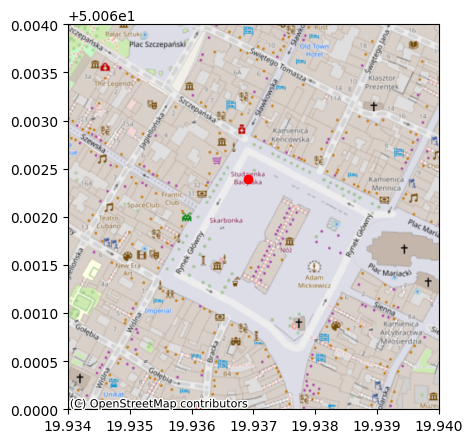

In [24]:
### Komórka testowa
gdf_1 = run_overpass_query(query_1, endpoint)
display(gdf_1.head())

fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_1.plot(ax=ax, color="red")
ax.set_xlim([19.934, 19.940])
ax.set_ylim([50.060, 50.064])
cx.add_basemap(ax, crs=gdf_1.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=17)
time.sleep(5)

#### b)
Przygotuj i zapisz do zmiennej `query_2` zapytanie pobierające z bazy danych OSM geometrię Zamku na Wawelu. W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
2) Korzystając z zapytania `way` oraz filtru `name` zdefiniuj zapytanie zapisujące wynik do zbioru domyślnego.
3) Wykonaj na zbiorze domyślnym operację rekursji w dół w celu pobrania geometrii wszystkich obiektów podrzędnych;
4) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [25]:
query_2 = """
[out:json][timeout:30];
way[name="Zamek Wawel"]; 
(._; >;);
out body;
"""

,geometry,type,id,nodes,historic,name,name:de,name:nl,name:pl,ref:ckkp,wikidata,wikipedia
0,"POLYGON ((19.93653 50.05531, 19.93652 50.05532...",way,785550415,"[2990175671, 2990175674, 2990175676, 299017567...",castle,Zamek Wawel,Wawelburg,Kasteel van Wawel,Wawel,MA00883,Q18820,pl:Zamek Królewski na Wawelu


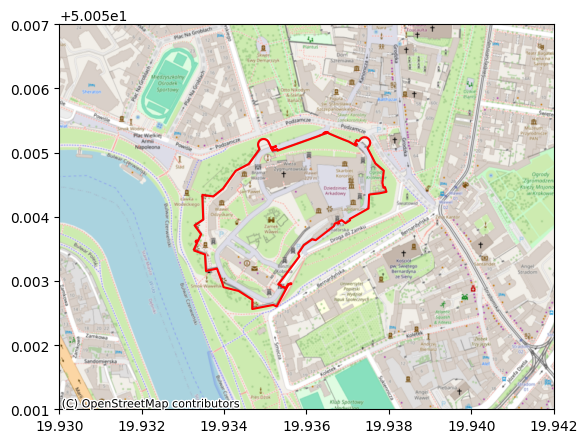

In [26]:
### Komórka testowa
gdf_2 = run_overpass_query(query_2, endpoint)
display(gdf_2.head())

fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_2.boundary.plot(ax=ax, color="red")
ax.set_xlim([19.93, 19.942])
ax.set_ylim([50.051, 50.057])
cx.add_basemap(ax, crs=gdf_2.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=17)
time.sleep(5)

#### c)
Przygotuj i zapisz do zmiennej `query_3` zapytanie pobierające z bazy danych OSM geometrię granic miasta Krakowa. W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
   - globalny prostokąt zapytania: [49.92, 19.7, 50.18, 20.3]
2) Korzystając z zapytania `rel` oraz filtrów `name`, `boundary` oraz `admin_level` zdefiniuj zapytanie zapisujące wynik do zbioru domyślnego.
3) Wykonaj na zbiorze domyślnym operację rekursji w dół w celu pobrania geometrii wszystkich obiektów podrzędnych;
4) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [29]:
query_3 = """
[out:json][timeout:30][bbox:49.92, 19.7, 50.18, 20.3];
rel[name="Kraków"][type=boundary][admin_level=6];
(._; >;);
out body;
"""

,geometry,type,id,capital,multi_postcode_place,name,name:ar,name:ast,name:be,name:br,...,wikipedia,admin_level,alt_name:en,boundary,name:prefix,name:zh,note,type,vehicle_plate_code,wikimedia_commons
0,POINT (19.93686 50.06195),node,1838666975,4,yes,Kraków,كراكوف,Cracovia,Кракаў,Krakovia,...,pl:Kraków,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"MULTIPOLYGON (((19.79265 50.01307, 19.79247 50...",relation,449696,NaN,NaN,Kraków,كراكوف,NaN,Кракаў,Krakovia,...,pl:Kraków,6,Cracow,administrative,miasto na prawach powiatu,克拉科夫,miasto na prawach powiatu,boundary,KR,Category:Kraków


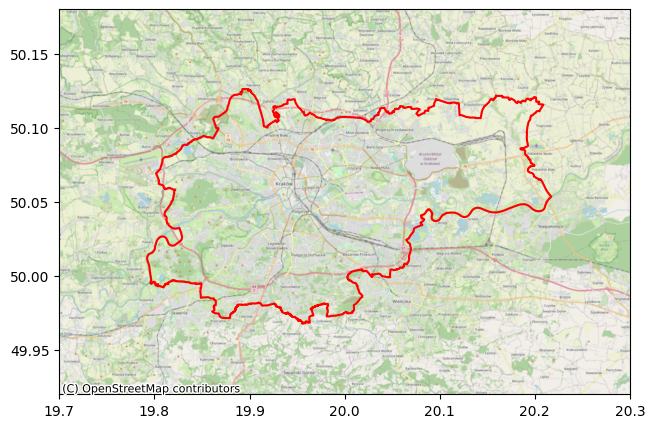

In [30]:
### Komórka testowa
gdf_3 = run_overpass_query(query_3, endpoint)
display(gdf_3.head())
fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_3.boundary.plot(ax=ax, color="red")
ax.set_xlim([19.7, 20.3])
ax.set_ylim([49.92, 50.18])
cx.add_basemap(ax, crs=gdf_3.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
time.sleep(5)

#### d)
Przygotuj i zapisz do zmiennej `query_4` zapytanie pobierające z bazy danych OSM punktowe oznaczenia szczytów w Krakowie i jego okolicach. W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
   - globalny prostokąt zapytania: [49.92, 19.7, 50.18, 20.3]
2) Korzystając z zapytania `node` oraz filtru `natural` zdefiniuj zapytanie zapisujące wynik do zbioru domyślnego.
3) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [31]:
query_4 = """
[out:json][timeout:30][bbox:49.92, 19.7, 50.18, 20.3];
node[natural=peak];
out body;
"""

,geometry,type,id,commemorates:wikidata,description,ele,fee,fee:conditional,heritage,heritage:operator,...,archaeological_site,name:es,name:fr,name:it,source:name,note,note_1,source,name:cs,name:uk
0,POINT (19.89335 50.05492),node,226153423,Q191479,Kopiec Kościuszki usypany w 1823 roku przez sp...,326.5,yes,"no @ 4 February, 24 March, 15 October",2,nid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POINT (19.84717 50.06005),node,274386820,NaN,The highest point in Kraków,383.6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POINT (19.95844 50.03808),node,288621733,NaN,stanowisko archeologiczne obiekt kultowy i poc...,269,NaN,NaN,2,nid,...,tumulus,Túmulo de Krakus,Tumulus de Krakus,Tumulo di Krakus,NaN,NaN,NaN,NaN,NaN,NaN
3,POINT (20.06808 50.07023),node,1271926784,NaN,NaN,238,NaN,NaN,NaN,NaN,...,NaN,Túmulo de Wanda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POINT (19.84545 50.0606),node,1904349128,NaN,NaN,354,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


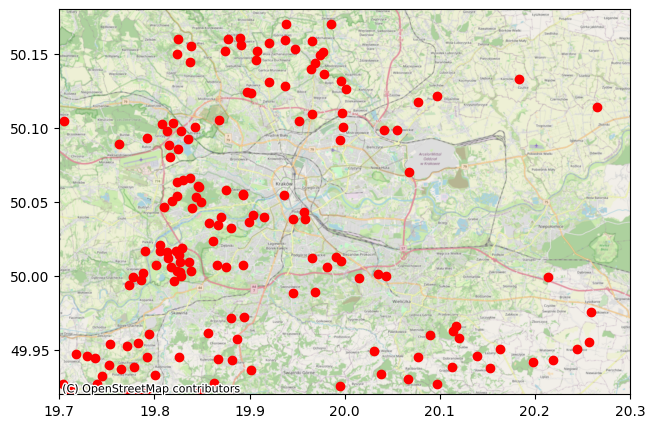

In [32]:
### Komórka testowa
gdf_4 = run_overpass_query(query_4, endpoint)
display(gdf_4.head())
fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_4.plot(ax=ax, color="red")
ax.set_xlim([19.7, 20.3])
ax.set_ylim([49.92, 50.18])
cx.add_basemap(ax, crs=gdf_4.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
time.sleep(5)

#### e)
Przygotuj i zapisz do zmiennej `query_5` zapytanie pobierające z bazy danych OSM punktowe oznaczenia szczytów w Krakowie. W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
   - globalny prostokąt zapytania: [49.92, 19.7, 50.18, 20.3]

2) Korzystając z zapytania `area` oraz filtrów `name`, `boundary` oraz `admin_level` zdefiniuj filtr przestrzenny zapisujący wynik do zbioru domyślnego.
3) Korzystając z zapytania `node` oraz filtru `natural` i przygotowanego filtru przestrzennego zdefiniuj zapytanie zapisujące wynik do zbioru domyślnego.
4) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [35]:
query_5 = """
[out:json][timeout:30][bbox:49.92, 19.7, 50.18, 20.3];
area[name="Kraków"][type=boundary][admin_level=6];
node[natural=peak](area);
out body;
"""

,geometry,type,id,commemorates:wikidata,description,ele,fee,fee:conditional,heritage,heritage:operator,...,archaeological_site,name:es,name:fr,name:it,source:name,note,note_1,source,name:cs,name:uk
0,POINT (19.89335 50.05492),node,226153423,Q191479,Kopiec Kościuszki usypany w 1823 roku przez sp...,326.5,yes,"no @ 4 February, 24 March, 15 October",2,nid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POINT (19.84717 50.06005),node,274386820,NaN,The highest point in Kraków,383.6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POINT (19.95844 50.03808),node,288621733,NaN,stanowisko archeologiczne obiekt kultowy i poc...,269,NaN,NaN,2,nid,...,tumulus,Túmulo de Krakus,Tumulus de Krakus,Tumulo di Krakus,NaN,NaN,NaN,NaN,NaN,NaN
3,POINT (20.06808 50.07023),node,1271926784,NaN,NaN,238,NaN,NaN,NaN,NaN,...,NaN,Túmulo de Wanda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POINT (19.84545 50.0606),node,1904349128,NaN,NaN,354,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


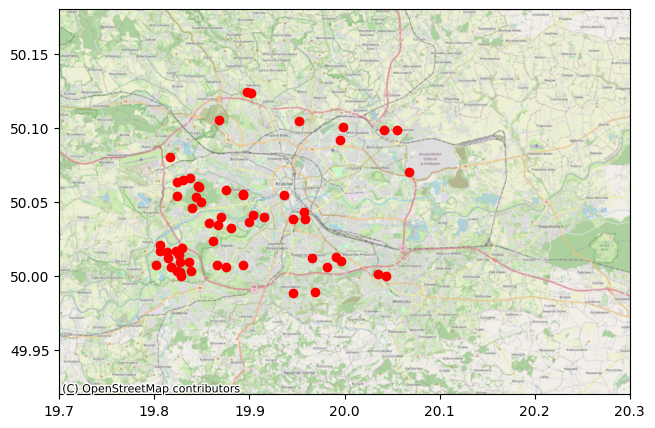

In [36]:
### Komórka testowa
gdf_5 = run_overpass_query(query_5, endpoint)
display(gdf_5.head())
fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_5.plot(ax=ax, color="red")
ax.set_xlim([19.7, 20.3])
ax.set_ylim([49.92, 50.18])
cx.add_basemap(ax, crs=gdf_5.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
time.sleep(5)

#### f)
Przygotuj i zapisz do zmiennej `query_6` zapytanie pobierające z bazy danych OSM punktowe oznaczenia szczytów w wybranych dzielnicach Krakowa (Zwierzyniec i Dębniki). W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
   - globalny prostokąt zapytania: [49.92, 19.7, 50.18, 20.3]
2) Korzystając z zapytania `area` oraz filtrów `name`, `boundary` oraz `admin_level` zdefiniuj filtr przestrzenny (Zwierzyniec) zapisujący wynik do zbioru nazwanego.
3) Korzystając z zapytania `area` oraz filtrów `name`, `boundary` oraz `admin_level` zdefiniuj filtr przestrzenny (Dębniki) zapisujący wynik do zbioru nazwanego.
4) Wykonaj na filtrach dzielnic operację `union` łącząc je w jeden zbiór nazwany.
5) Korzystając z zapytania `node` oraz filtru `natural` i przygotowanego filtru przestrzennego zdefiniuj zapytanie zapisujące wynik do zbioru domyślnego.
6) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [41]:
query_6 = """
[out:json][timeout:30][bbox:49.92, 19.7, 50.18, 20.3];
area[name="Zwierzyniec"][type=boundary][admin_level=9] -> .z;
area[name="Dębniki"][type=boundary][admin_level=9] -> .d;
(.z; .d;) -> .zd;
node[natural=peak](area.zd); 
out body;
"""

,geometry,type,id,commemorates:wikidata,description,ele,fee,fee:conditional,heritage,heritage:operator,...,wikidata,wikimedia_commons,wikipedia,tourism,wheelchair,source:name,note,note_1,alt_name,source
0,POINT (19.89335 50.05492),node,226153423,Q191479,Kopiec Kościuszki usypany w 1823 roku przez sp...,326.5,yes,"no @ 4 February, 24 March, 15 October",2,nid,...,Q641398,Category:Kościuszko Mound,pl:Kopiec Kościuszki w Krakowie,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POINT (19.84717 50.06005),node,274386820,NaN,The highest point in Kraków,383.6,NaN,NaN,NaN,NaN,...,Q1985405,NaN,pl:Kopiec Józefa Piłsudskiego w Krakowie,viewpoint,no,NaN,NaN,NaN,NaN,NaN
2,POINT (19.84545 50.0606),node,1904349128,NaN,NaN,354,NaN,NaN,NaN,NaN,...,Q9339872,NaN,pl:Sowiniec (wzgórze),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,POINT (19.8756 50.05777),node,1904448316,NaN,NaN,296.3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1. Geoportal https://mapy.geoportal.gov.pl/ 2....,NaN,NaN,NaN,NaN
4,POINT (19.84858 50.04998),node,2591418657,NaN,NaN,353,NaN,NaN,NaN,NaN,...,Q11831907,NaN,pl:Pustelnik (wzgórze),NaN,NaN,NaN,"rozbieżne dane, do zweryfikowania położenie i ...",NaN,NaN,NaN


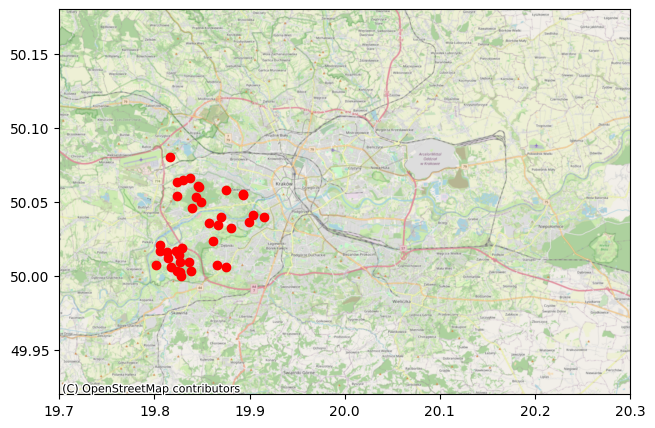

In [42]:
### Komórka testowa
gdf_6 = run_overpass_query(query_6, endpoint)
display(gdf_6.head())
fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_6.plot(ax=ax, color="red")
ax.set_xlim([19.7, 20.3])
ax.set_ylim([49.92, 50.18])
cx.add_basemap(ax, crs=gdf_6.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
time.sleep(5)

#### g)
Przygotuj i zapisz do zmiennej `query_7` zapytanie pobierające z bazy danych OSM punktowe oznaczenia szczytów leżących na terenie Krakowa, a jednocześnie poza obszarem Bielańsko-Tynieckiego Parku Krajobrazowego. W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
   - globalny prostokąt zapytania: [49.92, 19.7, 50.18, 20.3]
2) Korzystając z zapytania`area` oraz filtrów `name`, `boundary` oraz `admin_level` zdefiniuj filtr przestrzenny (Kraków) zapisujący wynik do zbioru nazwanego.
2) Korzystając z zapytania`node` oraz filtru `natural` i przygotowanego filtru przestrzennego zdefiniuj zapytanie zapisujące wynik do zbioru nazwanego.
3) Korzystając z zapytania`area` oraz filtrów `name` zdefiniuj filtr przestrzenny (Bielańsko-Tyniecki Park Krajobrazowy) zapisujący wynik do zbioru nazwanego.
5) Korzystając z zapytania`node` oraz filtru `natural` i przygotowanego filtru przestrzennego zdefiniuj zapytanie zapisujące wynik do zbioru nazwanego.
6) Wykonaj na zbiorach nazwanych operację `difference` zapisując różnicę zbiorów do zbioru domyślnego.
7) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [49]:
query_7="""
[out:json][timeout:30][bbox:49.92, 19.7, 50.18, 20.3];
area[name="Kraków"][type=boundary][admin_level=6] -> .krakow;
node[natural=peak](area.krakow) -> .peak_krakow;
area[name="Bielańsko-Tyniecki Park Krajobrazowy"] -> .park;
node[natural=peak](area.park) -> .peak_park; 
( .peak_krakow; - .peak_park; );
out body;
"""

,geometry,type,id,alt_name,alt_name:it,alt_name:pl,archaeological_site,description,ele,heritage,...,name:pl,natural,nid:inscription_date,ref:nid,tourism,wikidata,wikipedia,source,name:cs,name:uk
0,POINT (19.95844 50.03808),node,288621733,Kopiec Kraka,Tumulo di Krak,Kopiec Kraka,tumulus,stanowisko archeologiczne obiekt kultowy i poc...,269,2,...,Kopiec Krakusa,peak,1933-10-11,A-955,viewpoint,Q722446,pl:Kopiec Krakusa,NaN,NaN,NaN
1,POINT (20.06808 50.07023),node,1271926784,NaN,NaN,NaN,NaN,NaN,238,NaN,...,Kopiec Wandy,peak,NaN,NaN,NaN,Q421819,pl:Kopiec Wandy,NaN,NaN,NaN
2,POINT (19.94614 49.98836),node,3750902030,NaN,NaN,NaN,NaN,NaN,284,NaN,...,NaN,peak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,POINT (19.81605 50.08022),node,5520719969,NaN,NaN,NaN,NaN,NaN,258,NaN,...,NaN,peak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POINT (20.05492 50.09864),node,6794118978,NaN,NaN,NaN,NaN,NaN,273,NaN,...,NaN,peak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


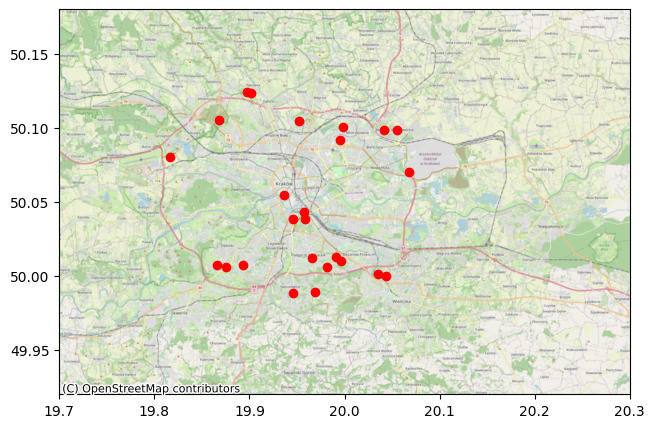

In [50]:
### Komórka testowa
gdf_7 = run_overpass_query(query_7, endpoint)
display(gdf_7.head())
fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_7.plot(ax=ax, color="red")
ax.set_xlim([19.7, 20.3])
ax.set_ylim([49.92, 50.18])
cx.add_basemap(ax, crs=gdf_7.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
time.sleep(5)

#### h)
Przygotuj i zapisz do zmiennej `query_8` zapytanie pobierające z bazy danych OSM punktowe oznaczenia szczytów leżących na terenie Krakowa, a jednocześnie w obszarze Bielańsko-Tynieckiego Parku Krajobrazowego. W tym celu:
1) Ustaw następujące wartości ustawień zapytania:
   - format odpowiedzi: json
   - maksymalny czas wykonania: 30s
   - globalny prostokąt zapytania: [49.92, 19.7, 50.18, 20.3]
2) Korzystając z zapytania`area` oraz filtrów `name`, `boundary` oraz `admin_level` zdefiniuj filtr przestrzenny (Kraków) zapisujący wynik do zbioru nazwanego.
2) Korzystając z zapytania`node` oraz filtru `natural` i przygotowanego filtru przestrzennego zdefiniuj zapytanie zapisujące wynik do zbioru nazwanego.
3) Korzystając z zapytania`area` oraz filtrów `name` zdefiniuj filtr przestrzenny (Bielańsko-Tyniecki Park Krajobrazowy) zapisujący wynik do zbioru nazwanego.
5) Korzystając z zapytania`node` oraz filtru `natural` i przygotowanego filtru przestrzennego zdefiniuj zapytanie zapisujące wynik do zbioru nazwanego.
6) Wykonaj na zbiorach nazwanych operację `intersection` zapisując część wspólną zbiorów do zbioru domyślnego.
7) Korzystając z instrukcji `out` zwróć wyniki zapytania w domyślnym trybie.

In [57]:
query_8="""
[out:json][timeout:30][bbox:49.92, 19.7, 50.18, 20.3];
area[name="Kraków"][type=boundary][admin_level=6] -> .krakow;
node[natural=peak](area.krakow) -> .peak_krakow;
area[name="Bielańsko-Tyniecki Park Krajobrazowy"] -> .park;
node[natural=peak](area.park) -> .peak_park; 
( .peak_krakow; - ( .peak_krakow; - .peak_park; ); );
out body;
"""

,geometry,type,id,commemorates:wikidata,description,ele,fee,fee:conditional,heritage,heritage:operator,...,website,wikidata,wikimedia_commons,wikipedia,tourism,wheelchair,source:name,note,note_1,alt_name
0,POINT (19.89335 50.05492),node,226153423,Q191479,Kopiec Kościuszki usypany w 1823 roku przez sp...,326.5,yes,"no @ 4 February, 24 March, 15 October",2,nid,...,https://kopieckosciuszki.pl/,Q641398,Category:Kościuszko Mound,pl:Kopiec Kościuszki w Krakowie,NaN,NaN,NaN,NaN,NaN,NaN
1,POINT (19.84717 50.06005),node,274386820,NaN,The highest point in Kraków,383.6,NaN,NaN,NaN,NaN,...,NaN,Q1985405,NaN,pl:Kopiec Józefa Piłsudskiego w Krakowie,viewpoint,no,NaN,NaN,NaN,NaN
2,POINT (19.84545 50.0606),node,1904349128,NaN,NaN,354,NaN,NaN,NaN,NaN,...,NaN,Q9339872,NaN,pl:Sowiniec (wzgórze),NaN,NaN,NaN,NaN,NaN,NaN
3,POINT (19.8756 50.05777),node,1904448316,NaN,NaN,296.3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1. Geoportal https://mapy.geoportal.gov.pl/ 2....,NaN,NaN,NaN
4,POINT (19.84858 50.04998),node,2591418657,NaN,NaN,353,NaN,NaN,NaN,NaN,...,NaN,Q11831907,NaN,pl:Pustelnik (wzgórze),NaN,NaN,NaN,"rozbieżne dane, do zweryfikowania położenie i ...",NaN,NaN


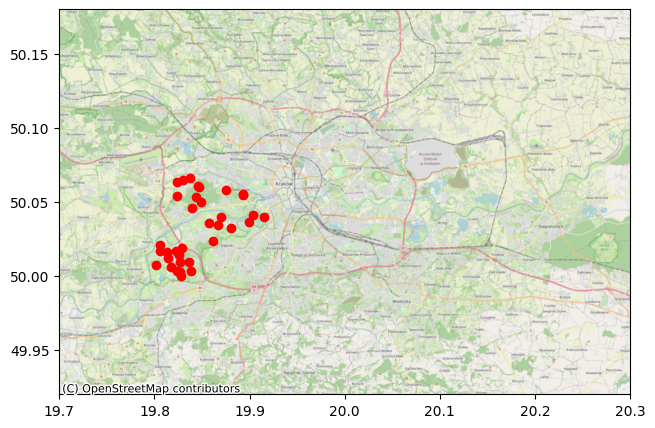

In [58]:
### Komórka testowa
gdf_8 = run_overpass_query(query_8, endpoint)
display(gdf_8.head())
fig, ax = plt.subplots(1, 1, figsize=(10,5))
gdf_8.plot(ax=ax, color="red")
ax.set_xlim([19.7, 20.3])
ax.set_ylim([49.92, 50.18])
cx.add_basemap(ax, crs=gdf_8.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
time.sleep(5)